## **Fashion Dataset Sorting (Classification)**

First let's import TensorFlow and Keras.

In [1]:
import tensorflow as tf
from tensorflow import keras
import numpy as np
import matplotlib.pyplot as plt

Let's start by loading the fashion MNIST dataset. Keras has a number of functions to load popular datasets in `keras.datasets`. The dataset is already split for you between a training set and a test set, but it can be useful to split the training set further to have a validation set:

In [2]:
fashion_mnist = keras.datasets.fashion_mnist

In [3]:
(X_train_full,y_train_full),(X_test,y_test) = fashion_mnist.load_data()

The training set contains 60,000 grayscale images, each 28x28 pixels:

In [4]:
X_train_full.shape

(60000, 28, 28)

In [5]:
X_test.shape

(10000, 28, 28)

Each pixel intensity is represented as a byte (0 to 255):

In [6]:
X_train_full.dtype

dtype('uint8')

Let's split the full training set into a validation set and a (smaller) training set. We also scale the pixel intensities down to the 0-1 range and convert them to floats, by dividing by 255.

In [7]:
X_valid,X_train = X_train_full[:5000] /255.,X_train_full[5000:] / 255.
y_valid,y_train = y_train_full[:5000],y_train_full[5000:]
X_test = X_test / 255

In [8]:
X_valid.shape

(5000, 28, 28)

In [9]:
X_test.shape

(10000, 28, 28)

In [10]:
len(y_valid)

5000

You can plot an image using Matplotlib's `imshow()` function, with a `'binary'`
 color map:

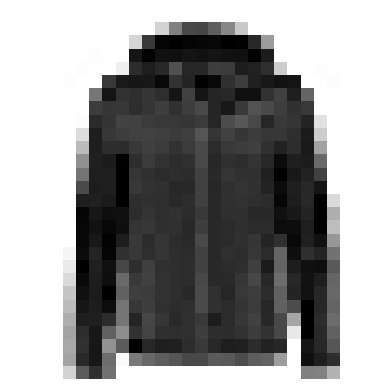

In [11]:
plt.imshow(X_train[0],cmap='binary')
plt.axis('off')
plt.show()

The labels are the class IDs (represented as uint8), from 0 to 9:

In [12]:
y_train

array([4, 0, 7, ..., 3, 0, 5], shape=(55000,), dtype=uint8)

In [13]:
y_train[0]

np.uint8(4)

Here are the corresponding class names:

In [14]:
class_names = ["T-shirt/top", "Trouser", "Pullover", "Dress", "Coat",
               "Sandal", "Shirt", "Sneaker", "Bag", "Ankle boot"]

So the first image in the training set is a coat:

In [15]:
class_names[y_train[0]]

'Coat'

The validation set contains 5,000 images, and the test set contains 10,000 images:

In [16]:
X_valid.shape

(5000, 28, 28)

In [17]:
X_test.shape

(10000, 28, 28)

Let's take a look at a sample of the images in the dataset:

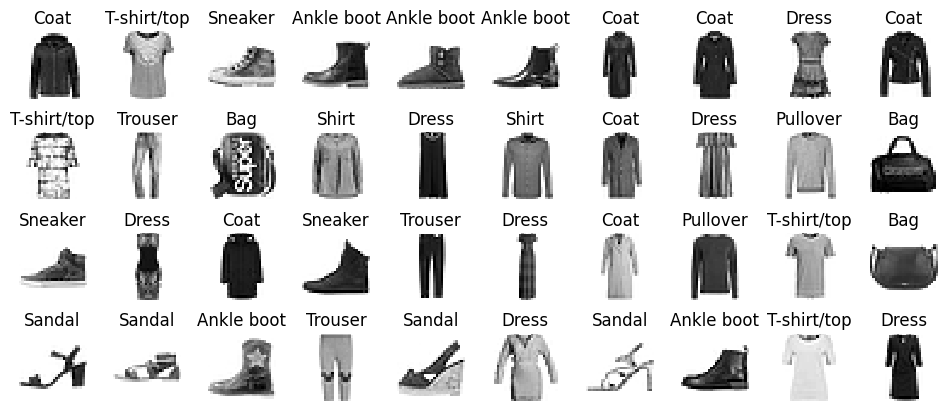

In [18]:
n_rows = 4
n_cols = 10
plt.figure(figsize=(n_cols * 1.2,n_rows * 1.2))
for row in range(n_rows):
    for col in range(n_cols):
        index = n_cols * row + col
        plt.subplot(n_rows,n_cols ,index+1)
        plt.imshow(X_train[index],cmap='binary',interpolation='nearest')
        plt.axis('off')
        plt.title(class_names[y_train[index]],fontsize=12)

plt.subplots_adjust(wspace=0.2,hspace=0.5)
plt.show()

In [19]:
model = keras.models.Sequential()
model.add(keras.layers.Flatten(input_shape=[28,28]))
model.add(keras.layers.Dense(300,activation='relu'))
model.add(keras.layers.Dense(100,activation='relu'))
model.add(keras.layers.Dense(10,activation='softmax'))

/Users/fahimp/Desktop/Python_Frameworks/neural-network-from-scratch/nn/lib/python3.11/site-packages/keras/src/layers/reshaping/flatten.py:37: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


In [20]:
keras.backend.clear_session()
np.random.seed(42)
tf.random.set_seed(42)

In [21]:
model.layers

[<Flatten name=flatten, built=True>,
 <Dense name=dense, built=True>,
 <Dense name=dense_1, built=True>,
 <Dense name=dense_2, built=True>]

In [22]:
model.summary()

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ flatten (Flatten)               │ (None, 784)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 300)            │       235,500 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 100)            │        30,100 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 10)             │         1,010 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 266,610 (1.02 MB)

 Trainable params: 266,610 (1.02 MB)

 Non-trainable params: 0 (0.00 B)

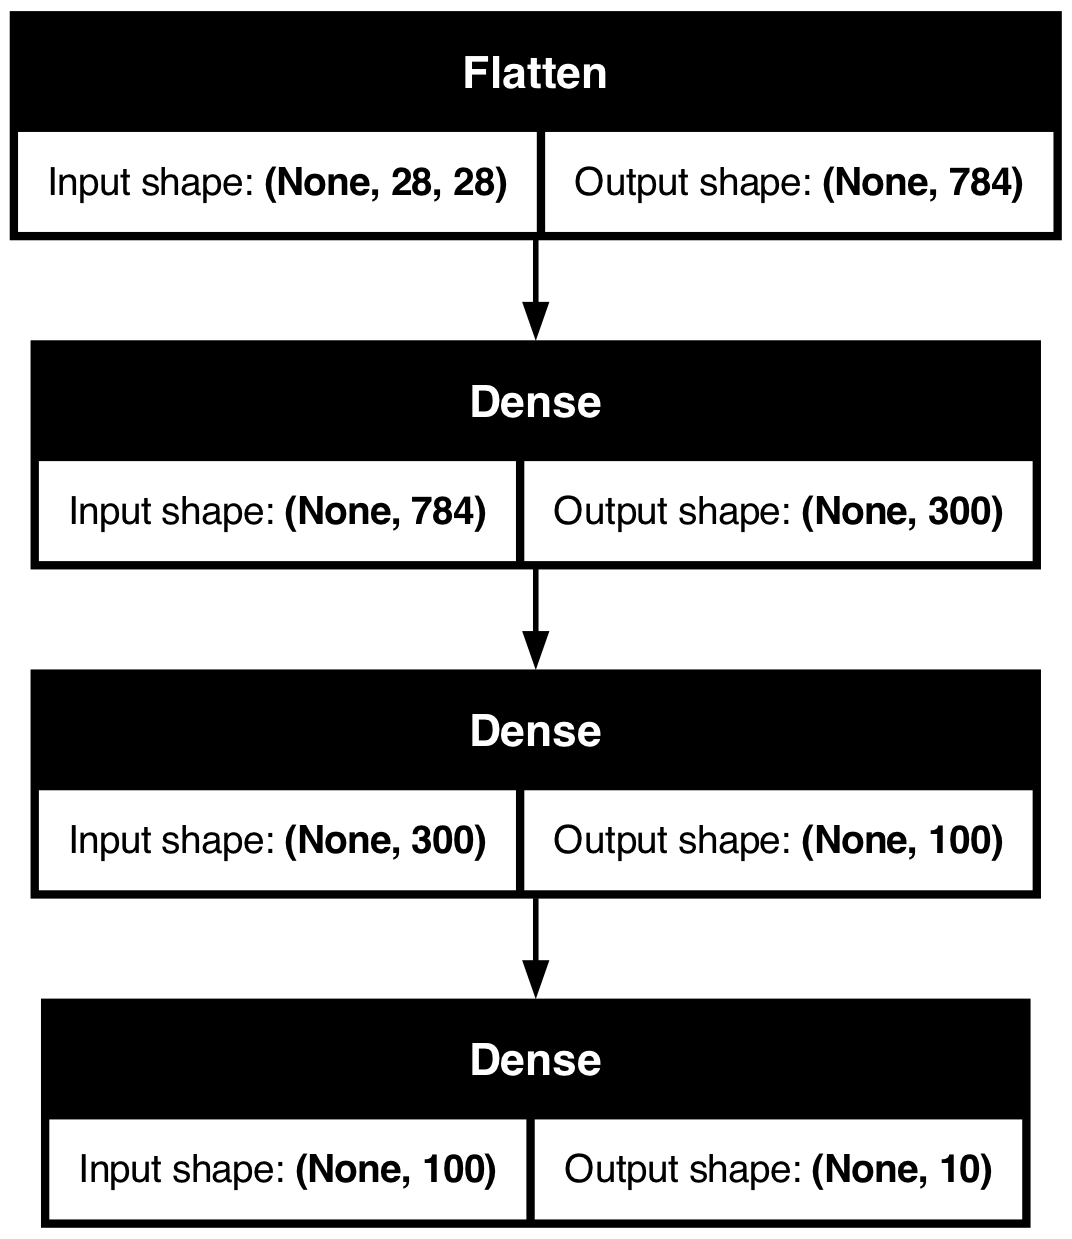

In [30]:
keras.utils.plot_model(model,'my_fashion_mnist_model.png',show_shapes=True)

In [29]:
hidden1 = model.layers[1]
hidden1.name

'dense'

In [27]:
model.get_layer(hidden1.name)is hidden1

True

In [34]:
weights,biases = hidden1.get_weights()
weights

array([[-0.05532933, -0.04393223, -0.00868557, ...,  0.03266014,
        -0.01575262,  0.04195832],
       [ 0.01860222, -0.01742826, -0.06519857, ..., -0.06153171,
        -0.00045588,  0.0078195 ],
       [-0.01868415,  0.01135141,  0.03761869, ..., -0.04190595,
        -0.02571593, -0.04988866],
       ...,
       [ 0.01190127,  0.05494638,  0.07232925, ...,  0.02546468,
         0.05623817, -0.06869747],
       [-0.01845008, -0.03874141,  0.06942227, ..., -0.02394802,
        -0.01839722, -0.04180035],
       [-0.03236938,  0.06855991,  0.02041151, ...,  0.0691056 ,
        -0.01458374, -0.01139042]], shape=(784, 300), dtype=float32)

In [35]:
weights.shape

(784, 300)

In [37]:
biases

array([0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0.,
       0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0.,
       0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0.,
       0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0.,
       0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0.,
       0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0.,
       0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0.,
       0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0.,
       0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0.,
       0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0.,
       0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0.,
       0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0.,
       0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0.,
       0., 0., 0., 0., 0.

In [36]:
biases.shape

(300,)

In [38]:
model.compile(loss='sparse_categorical_crossentropy',
              optimizer = 'sgd',
              metrics = ['accuracy'])

This is equivalent to:

In [ ]:
model.compile(loss=keras.losses.sparse_categorical_crossentropy,
              optimizer=keras.optimizers.SGD(),
              metrics=[keras.metrics.sparse_categorical_accuracy])

In [39]:
history = model.fit(X_train,y_train,epochs=30,
                    validation_data = (X_valid,y_valid))

Epoch 1/30
1719/1719 ━━━━━━━━━━━━━━━━━━━━ 2s 749us/step - accuracy: 0.7607 - loss: 0.7341 - val_accuracy: 0.8192 - val_loss: 0.5308
Epoch 2/30
1719/1719 ━━━━━━━━━━━━━━━━━━━━ 1s 688us/step - accuracy: 0.8283 - loss: 0.4916 - val_accuracy: 0.8408 - val_loss: 0.4667
Epoch 3/30
1719/1719 ━━━━━━━━━━━━━━━━━━━━ 1s 696us/step - accuracy: 0.8435 - loss: 0.4465 - val_accuracy: 0.8516 - val_loss: 0.4284
Epoch 4/30
1719/1719 ━━━━━━━━━━━━━━━━━━━━ 1s 687us/step - accuracy: 0.8533 - loss: 0.4182 - val_accuracy: 0.8592 - val_loss: 0.4058
Epoch 5/30
1719/1719 ━━━━━━━━━━━━━━━━━━━━ 1s 736us/step - accuracy: 0.8601 - loss: 0.3975 - val_accuracy: 0.8658 - val_loss: 0.3892
Epoch 6/30
1719/1719 ━━━━━━━━━━━━━━━━━━━━ 1s 766us/step - accuracy: 0.8647 - loss: 0.3809 - val_accuracy: 0.8698 - val_loss: 0.3761
Epoch 7/30
1719/1719 ━━━━━━━━━━━━━━━━━━━━ 1s 663us/step - accuracy: 0.8696 - loss: 0.3668 - val_accuracy: 0.8720 - val_loss: 0.3667
Epoch 8/30
1719/1719 ━━━━━━━━━━━━━━━━━━━━ 1s 662us/step - accuracy: 0.8734 -

In [40]:
history.params

{'verbose': 'auto', 'epochs': 30, 'steps': 1719}

In [41]:
print(history.epoch)

[0, 1, 2, 3, 4, 5, 6, 7, 8, 9, 10, 11, 12, 13, 14, 15, 16, 17, 18, 19, 20, 21, 22, 23, 24, 25, 26, 27, 28, 29]


In [42]:
history.history.keys()

dict_keys(['accuracy', 'loss', 'val_accuracy', 'val_loss'])

In [46]:
import pandas as pd

pd.DataFrame(history.history)

,accuracy,loss,val_accuracy,val_loss
0,0.760655,0.734071,0.8192,0.530757
1,0.828273,0.491597,0.8408,0.466662
2,0.843509,0.446490,0.8516,0.428361
3,0.853309,0.418194,0.8592,0.405811
4,0.860091,0.397527,0.8658,0.389180
5,0.864727,0.380904,0.8698,0.376077
6,0.869600,0.366825,0.8720,0.366655
7,0.873418,0.354924,0.8734,0.359141
8,0.877236,0.344489,0.8752,0.352808
9,0.879491,0.335276,0.8786,0.346748


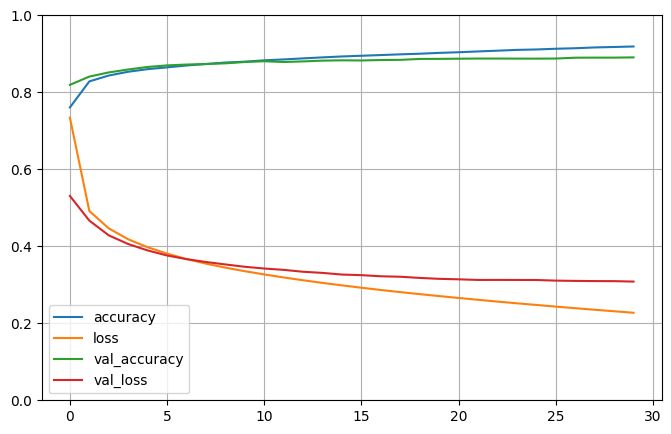

In [47]:
pd.DataFrame(history.history).plot(figsize=(8,5))
plt.grid(True)
plt.gca().set_ylim(0,1)
plt.show()

In [49]:
model.evaluate(X_test,y_test)

313/313 ━━━━━━━━━━━━━━━━━━━━ 0s 468us/step - accuracy: 0.8750 - loss: 0.3497


[0.34970954060554504, 0.875]

## TESTING

In [50]:
X_new = X_test[:3]

**This is how the test data looks like**

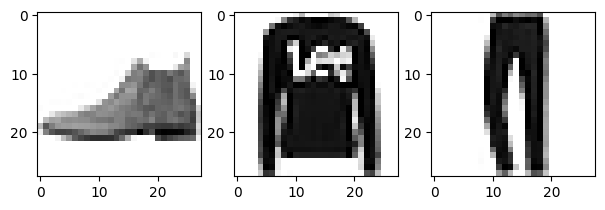

In [52]:
plt.figure(figsize=(7.2, 2.4))
for index,image in enumerate(X_new):
    plt.subplot(1, 3, index + 1)
    plt.imshow(image, cmap="binary", interpolation="nearest")
plt.subplots_adjust(wspace=0.2, hspace=0.5)
plt.show()

Warning: model.predict_classes(X_new) is deprecated. It is replaced with np.argmax(model.predict(X_new), axis=-1).

Let's see what our neural network predicts

In [57]:
y_pred = np.argmax(model.predict(X_new),axis=-1)
y_pred

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 14ms/step


array([9, 2, 1])

In [58]:
np.array(class_names)[y_pred]

array(['Ankle boot', 'Pullover', 'Trouser'], dtype='<U11')

In [59]:
y_new = y_test[:3]
y_new

array([9, 2, 1], dtype=uint8)

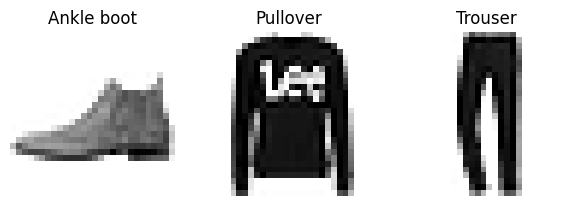

In [66]:
plt.figure(figsize=(7.2, 2.4))
for index, image in enumerate(X_new):
    plt.subplot(1, 3, index + 1)
    plt.imshow(image, cmap="binary", interpolation="nearest")
    plt.axis('off')
    plt.title(class_names[y_test[index]], fontsize=12)
plt.subplots_adjust(wspace=0.2, hspace=0.5)
plt.show()

**Awesome! We obtained perfect results :)**

```
# This is formatted as code
```

